#### Karnaugh Neural Network (KNN)
In Karnaugh Neural Network (KNN), we need to figer out the K, the K is actually the value that would show that how much nearest data points should include in the prediction scenerio.

Suppose we have trained 100 data points to the model and wants to predict or test for a new value. the model would predict the value of given data points from all. But if we define K = 3 the model will only go through the most accurate and nearest 3 data points. But if we define K = 10 and the model have found 7 mathching and nearest data points from class A and 3 from class B, here the model would choose the class that has more mathcing values. In our case it is class A.

In KNN we need to figer out which data point is most accurate or most near to given K. The algrithm would find out most accurate data point that is nearer to the given K, and will classify the K in that perticaler class.

> K should not have to be too large or too small, it depends on dataset mostly and classes

In [128]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.metrics import confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
iris = load_iris()

In [4]:
iris.data

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [5]:
iris.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [6]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [7]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [8]:
dataset = pd.DataFrame(iris.data, columns=iris.feature_names)

In [21]:
dataset.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,flower_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [10]:
dataset["target"] = iris.target

In [12]:
dataset["flower_name"] = dataset["target"].apply(lambda x:  iris.target_names[x])

In [22]:
setosa = dataset[:50]
versicolor = dataset[50:100]
verginica = dataset[100:150]

#### Visalize according to Petal Length and width

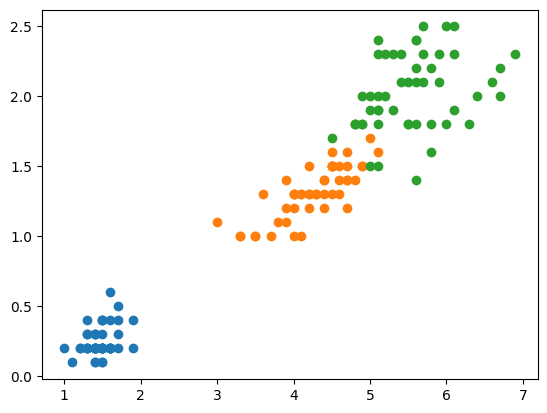

In [33]:
plt.scatter(setosa["petal length (cm)"],setosa["petal width (cm)"])
plt.scatter(versicolor["petal length (cm)"],versicolor["petal width (cm)"])
plt.scatter(verginica["petal length (cm)"],verginica["petal width (cm)"])

#### Visualize according to sepal length and width

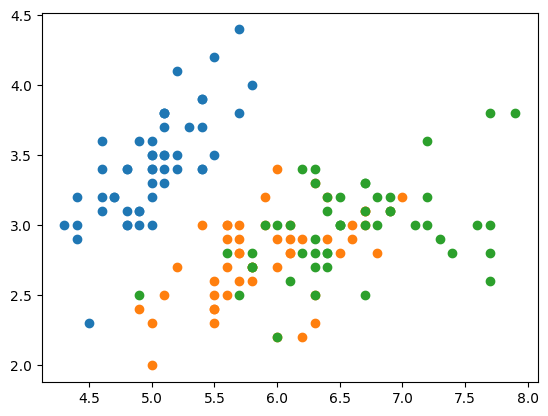

In [31]:
plt.scatter(setosa["sepal length (cm)"],setosa["sepal width (cm)"])
plt.scatter(versicolor["sepal length (cm)"],versicolor["sepal width (cm)"])
plt.scatter(verginica["sepal length (cm)"],verginica["sepal width (cm)"])

In [35]:
X, y = dataset.drop(columns=["flower_name","target"]), dataset["target"]

In [45]:
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [41]:
y[:5]

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int32

In [90]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=12)

In [152]:
KNN =KNeighborsClassifier(n_neighbors=12)

In [153]:
KNN.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=12)

In [154]:
y_predict = KNN.predict(X_test)

In [155]:
KNN.score(X_train,y_train)

0.9833333333333333

In [156]:
KNN.score(X_test,y_test)

1.0

In [157]:
matrix = confusion_matrix(y_test,y_predict)
matrix

array([[12,  0,  0],
       [ 0,  9,  0],
       [ 0,  0,  9]], dtype=int64)

In [158]:
setosa_counter = 0
versicolor_counter = 0
verginica_counter = 0
for i in y_test:
    if(i==0):
        setosa_counter = setosa_counter +1
    elif(i==1):
        versicolor_counter = versicolor_counter+1
    else:
        verginica_counter = verginica_counter+1
print(f"Setosa = {setosa_counter}, Vericolor = {versicolor_counter}, Verginica = {verginica_counter}")


Setosa = 12, Vericolor = 9, Verginica = 9


Text(50.722222222222214, 0.5, 'Actual')

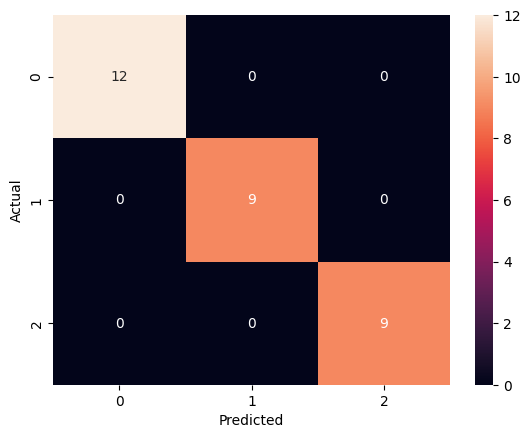

In [159]:
sns.heatmap(matrix,annot=True)
plt.xlabel("Predicted")
plt.ylabel("Actual")

#### predict unseen data

In [189]:
predict = [0.1,0.5,4.4,4.5]

In [190]:
KNN.predict_proba([predict])

c:\Users\Sakhi Larik\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array([[0.        , 0.66666667, 0.33333333]])

In [191]:
iris.target_names[KNN.predict([predict])][0]

c:\Users\Sakhi Larik\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


'versicolor'